<div style="text-align: justify; max-width: 90ch">

# Logging Plots with MLflow (across an Optuna sweep)

</div>

<div style="text-align: justify; max-width: 90ch">

Plots tell you things tables don't — whether residuals are heteroscedastic, whether predictions miss on a specific slice,
whether errors are normally distributed. The question this notebook answers is twofold:

1. **Where should those plots live so that, six weeks from now, you can still tell which run they belonged to?**
2. **When you're sweeping hyperparameters, how do you keep each trial's plots together with its params and metrics?**

Saving figures as PNGs in a `plots/` folder loses the link to the run that produced them. MLflow's answer is `mlflow.log_figure(fig, "name.png")`:
the figure is stored as a **run artifact**, side-by-side with the params, metrics, and model, and rendered inline in the UI's Artifacts tab.
In a tuning sweep, that pattern composes naturally with the parent/child run structure from `b_hyperparameter_tuning.ipynb`:

- **Per-trial diagnostic plots** (residuals, predicted-vs-actual, Q–Q) → logged to the **child run**. They describe one specific fit.
- **Per-dataset EDA plots** (correlation heatmap, feature-vs-target scatter) → logged once to the **parent run**. They describe the data, not the model.

This notebook is a modification of the official MLflow tutorial: **[Logging plots with MLflow](https://mlflow.org/docs/latest/ml/traditional-ml/tutorials/hyperparameter-tuning/part2-logging-plots/)**.
Where this notebook corrects, supplements, or deliberately diverges from upstream, the relationship is named with an inline bold callout —
one of **Bug**, **Stale**, **Missing from**, or **Diverges from upstream tutorial:** — or, in code cells, with a `NOTE (differs from upstream)` comment.
Sections with no upstream counterpart use a plain heading and no callout.

Three structural differences worth knowing up front:

- **Diverges from upstream tutorial:** upstream demonstrates plot logging on a **single** Ridge regression run. This notebook applies the same pattern across an **Optuna sweep** (5 trials, RandomForestRegressor —
  same setup as `b_hyperparameter_tuning.ipynb`), so you see how plots and metrics differ trial-to-trial.
- **Diverges from upstream tutorial:** upstream uses a custom "demand / weekday / weekend / price" dataset that it never explains.
  This notebook uses **California housing**, the same dataset as `b_`, so the focus stays on the plot-logging API.
- **Diverges from upstream tutorial:** upstream shows nine plots (time series, box, density, coefficients, …). This notebook keeps the five most teaching-relevant:
  a **correlation heatmap** and a **feature-vs-target scatter** as EDA, and **residuals**, **predicted-vs-actual**, **Q–Q** as per-trial diagnostics.
  The pattern is the same for the others — once you've logged one, you've logged them all.

</div>

<div style="text-align: justify; max-width: 90ch">

## Prerequisites

**Diverges from upstream tutorial:** Upstream says `pip install matplotlib seaborn`. This repo uses **`uv` exclusively** for dependency management —
`pip` is explicitly forbidden (see `CLAUDE.md`). `matplotlib` and `scipy` are already pulled in transitively. `optuna` was added by `b_hyperparameter_tuning.ipynb`;
you only need `seaborn` for the heatmap if it isn't already installed:

```bash
uv add seaborn
```

Commit `pyproject.toml` and `uv.lock` together.

### Start the tracking server

**Missing from upstream tutorial:** Before running any cell that calls `mlflow.set_tracking_uri(...)`, start the MLflow server **in a separate terminal**,
from `src/`:

```bash
cd src/
mlflow ui --host 127.0.0.1 --port 5001
```

Starting from `src/` keeps per-developer runtime state (`mlflow.db`, `mlartifacts/`) inside the source tree — same convention as the previous notebooks.
Update `PORT` below if you use a different port.

</div>

<div style="text-align: justify; max-width: 90ch">

## Why log plots to MLflow?

The same plot saved in three different places has three different futures:

| Where you saved it                 | Six weeks later, can you tell which run it came from?                                                                                         |
| ---------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| Inline in a notebook               | Only if the notebook was re-run since — otherwise the figure is from some prior run with prior params.                                        |
| `plots/residuals.png` in your repo | No. There's no link to a `run_id`, params, or metrics; one careless `git add` and the file silently outlives the experiment that produced it. |
| MLflow run artifact                | Yes. The figure is bundled with its `run_id`, every param, every metric, the data signature, and the model.                                   |

That last column is what `mlflow.log_figure(fig, "name.png")` buys you. In a tuning sweep the payoff is multiplied:

- **You see *how* each trial failed**, not just whether it did. Two trials with similar MSE can have very different residual patterns —
  one tilted, one fanned — and that tells you which is closer to a model misspecification vs random noise.
- **The UI renders them inline.** Click a child run → Artifacts tab → the PNGs preview without leaving the browser.
- **They survive a re-run.** Every `start_run()` produces its own artifact directory, so re-running this notebook never overwrites yesterday's plots.

</div>

<div style="text-align: justify; max-width: 90ch">

## The plot-function pattern

Each plot below lives inside a small function that **builds the figure and returns it** — it does not call `plt.show()`, and it does not log anything itself.
The logging happens at well-defined points: once on the parent run for EDA, once per trial on the child run for diagnostics.

Why this split?

- **The function is reusable.** You can call it from a notebook for ad-hoc exploration, from a training script for production logging,
  or from a test — without changing the function.
- **The run stays atomic.** Either all diagnostic figures for a trial land on the same child run, or none do.
- **Figures are values, not side effects.** Returning the `Figure` object makes the function testable and easy to compose;
  `plt.show()`-style code is implicit global state.

</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

import mlflow

HOST = "127.0.0.1"
PORT = 5001
mlflow.set_tracking_uri(uri=f"http://{HOST}:{PORT}")

# set_experiment creates the experiment if it doesn't exist yet and reuses it
# otherwise, so re-running this cell is safe.
experiment_name = "Logging Plots with MLflow"
mlflow.set_experiment(experiment_name)

2026/10/04 16:56:49 INFO mlflow.tracking.fluent: Experiment with name 'Logging Plots with MLflow' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/4', creation_time=1791122209564, experiment_id='4', last_update_time=1791122209564, lifecycle_stage='active', name='Logging Plots with MLflow', tags={}, trace_location=None, workspace='default'>

<div style="text-align: justify; max-width: 90ch">

## Step 1: Load the data

California housing: 8 numeric features (median income, house age, average rooms, …), one regression target (median house value, in $100k).
Same dataset as `b_hyperparameter_tuning.ipynb` so the comparison stays apples-to-apples.

</div>

In [2]:
raw = fetch_california_housing(as_frame=True)
df = raw.frame  # features + target in one DataFrame, handy for the heatmap below
X, y = raw.data, raw.target

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=0)
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


<div style="text-align: justify; max-width: 90ch">

## Step 2: Define the plot functions

Five functions, all returning a `matplotlib.figure.Figure`. Two for EDA (you'd run these *before* picking a model — they describe the dataset), three for diagnostics (you'd run these *after* fitting each candidate —
they describe a specific fit).

</div>

In [3]:
def plot_correlation_heatmap(frame: pd.DataFrame) -> plt.Figure:
    """Heatmap of pairwise Pearson correlations across features + target."""
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = frame.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide upper triangle
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
    ax.set_title("Feature \u2194 target correlations")
    fig.tight_layout()
    return fig


def plot_feature_vs_target(
    frame: pd.DataFrame, feature: str, target: str
) -> plt.Figure:
    """Scatter of one feature against the target. Pick the strongest predictor for the most useful plot."""
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(frame[feature], frame[target], s=4, alpha=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f"{feature} vs {target}")
    fig.tight_layout()
    return fig


def plot_residuals(y_true: np.ndarray, y_pred: np.ndarray) -> plt.Figure:
    """Residuals vs predicted. Healthy: flat band around 0. Unhealthy: a funnel, a curve, or a tilt."""
    fig, ax = plt.subplots(figsize=(7, 5))
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, s=4, alpha=0.3)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("predicted")
    ax.set_ylabel("residual (true \u2212 predicted)")
    ax.set_title("Residuals vs predicted")
    fig.tight_layout()
    return fig


def plot_predicted_vs_actual(y_true: np.ndarray, y_pred: np.ndarray) -> plt.Figure:
    """Predicted vs actual with the y = x reference line. Points off the diagonal are model error."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=4, alpha=0.3)
    lo, hi = (
        float(min(y_true.min(), y_pred.min())),
        float(max(y_true.max(), y_pred.max())),
    )
    ax.plot([lo, hi], [lo, hi], color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted")
    ax.set_title("Predicted vs actual")
    fig.tight_layout()
    return fig


def plot_qq(residuals: np.ndarray) -> plt.Figure:
    """Q\u2013Q plot of residuals against a normal distribution. Straight line = residuals are roughly normal."""
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title("Q\u2013Q plot of residuals (vs normal)")
    fig.tight_layout()
    return fig


# Quick check: a plot function returns a Figure and logs nothing; Step 5 does the logging.
preview = plot_feature_vs_target(df, "MedInc", "MedHouseVal")
print(
    f"{type(preview).__name__} with {len(preview.axes)} axes, not logged anywhere yet"
)
plt.close(preview)  # close it so Jupyter does not also draw it inline

Figure with 1 axes, not logged anywhere yet


<div style="text-align: justify; max-width: 90ch">

## Step 3: Define the metrics helper

Most tuning loops only log the single number they're optimizing — usually MSE. That makes the sweep cheap, but it costs you information:
a model with low MSE can still have ugly residual structure, and a model with slightly higher MSE can be the better choice if its errors are more uniform.

Logging a handful of complementary metrics on every trial gives you that picture without much extra cost. The five below cover the most common questions:

| Metric                 | What it tells you                                                                                     |
| ---------------------- | ----------------------------------------------------------------------------------------------------- |
| **MSE**                | Squared-error magnitude. The thing Optuna minimizes. Penalizes large errors quadratically.            |
| **RMSE**               | √MSE, in the target's units ($100k here). Easier to communicate than MSE.                             |
| **MAE**                | Mean absolute error. Less sensitive to outliers than MSE — read it alongside MSE to spot heavy tails. |
| **R²**                 | Fraction of variance explained (`1 - SS_res/SS_tot`). Unitless, useful for comparing across datasets. |
| **Explained variance** | Like R² but excludes systematic bias. If the two diverge, your predictions have a constant offset.    |

</div>

In [4]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Return five complementary regression metrics as a flat dict, ready for mlflow.log_metrics."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
        "explained_variance": float(explained_variance_score(y_true, y_pred)),
    }


# Quick check: predictions with a constant +0.5 offset. R² drops below 1, but explained
# variance stays at 1.0, because it ignores the offset (the bias case in the table above).
compute_metrics(np.array([1.0, 2.0, 3.0]), np.array([1.5, 2.5, 3.5]))

{'mse': 0.25, 'rmse': 0.5, 'mae': 0.5, 'r2': 0.625, 'explained_variance': 1.0}

<div style="text-align: justify; max-width: 90ch">

## Step 4: Define the objective function

Same parent/child pattern as `b_hyperparameter_tuning.ipynb` (open a `nested=True` child run per trial, stash the `run_id` on the trial for later lookup).
The new pieces are:

- `mlflow.log_metrics(compute_metrics(...))` — five metrics per child instead of one.
- Three diagnostic figures per child, each logged with `mlflow.log_figure(...)` — residuals, predicted-vs-actual, Q–Q. Switching between child runs in the UI now lets you compare *how* each trial fails, not just *whether* it did.
  Every trial logs all three, but only trial 0's figures stay open, so the notebook shows one set inline; the other trials' figures are closed once they are logged.
- `trial.set_user_attr("metrics", metrics)` — stash the full metric dict on the Optuna trial so the parent-run cell below can promote every "best\_\*" metric in one go,
  without re-querying MLflow.

</div>

In [5]:
# NOTE (differs from upstream tutorial): serialization_format="skops" avoids
# pickle/cloudpickle. See `b_tracking_quickstart.ipynb` for the full rationale.


def objective(trial: optuna.Trial) -> float:
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:
        params = {
            "max_depth": trial.suggest_int("rf_max_depth", 2, 32),
            "n_estimators": trial.suggest_int("rf_n_estimators", 50, 300, step=10),
            "max_features": trial.suggest_float("rf_max_features", 0.2, 1.0),
        }
        mlflow.log_params(params)

        regressor = RandomForestRegressor(**params, random_state=0)
        regressor.fit(X_train, y_train)
        y_pred = regressor.predict(X_val)

        metrics = compute_metrics(y_val.values, y_pred)
        mlflow.log_metrics(metrics)

        # Per-trial diagnostic plots \u2014 they describe *this* fit, so they belong on the child run.
        residuals = y_val.values - y_pred
        figures = {
            "diagnostics/residuals.png": plot_residuals(y_val.values, y_pred),
            "diagnostics/predicted_vs_actual.png": plot_predicted_vs_actual(
                y_val.values, y_pred
            ),
            "diagnostics/qq.png": plot_qq(residuals),
        }
        for artifact_file, fig in figures.items():
            mlflow.log_figure(fig, artifact_file)
            # Every trial's figures are in MLflow now. Only trial 0's stay open, so the
            # notebook draws one set inline instead of three per trial.
            if trial.number > 0:
                plt.close(fig)

        mlflow.sklearn.log_model(
            regressor,
            name="model",
            serialization_format="skops",
        )

        # Stash both the run_id and the full metric dict on the trial \u2014 the
        # parent-run cell below promotes every metric onto the parent at once.
        trial.set_user_attr("run_id", child_run.info.run_id)
        trial.set_user_attr("metrics", metrics)
        return metrics["mse"]


print(
    f"objective() is ready: each trial trains on {len(X_train):,} rows "
    f"and scores {len(X_val):,} validation rows."
)

objective() is ready: each trial trains on 15,480 rows and scores 5,160 validation rows.


<div style="text-align: justify; max-width: 90ch">

## Step 5: Run the study and log EDA on the parent

The parent run scopes the whole sweep. **Before** calling `study.optimize(...)`, we log the EDA plots to the parent — they describe the dataset, so they belong on the run that represents the *whole study*, not on any one trial.
**After** `optimize` returns, we promote the best trial's params and all five metrics onto the parent so the UI's runs table is useful at a glance.

</div>

[I 2026-10-04 16:56:50,172] A new study created in memory with name: no-name-e48f303f-b126-4a12-b5ed-128e1bc3ccac


2026/10/04 16:57:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[I 2026-10-04 16:57:10,043] Trial 0 finished with value: 0.2523528496676865 and parameters: {'rf_max_depth': 25, 'rf_n_estimators': 260, 'rf_max_features': 0.6091804732802633}. Best is trial 0 with value: 0.2523528496676865.


🏃 View run trial_0 at: http://127.0.0.1:5001/#/experiments/4/runs/fd58a86fad3241fc944e26c20f228e0b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4


2026/10/04 16:57:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


...

🏃 View run trial_3 at: http://127.0.0.1:5001/#/experiments/4/runs/ce4d276658a04e7d8729ba6ced2963e0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4


2026/10/04 16:57:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[I 2026-10-04 16:57:47,203] Trial 4 finished with value: 0.2928754647448661 and parameters: {'rf_max_depth': 10, 'rf_n_estimators': 70, 'rf_max_features': 0.46649455622910846}. Best is trial 1 with value: 0.24706490320580002.


🏃 View run trial_4 at: http://127.0.0.1:5001/#/experiments/4/runs/df997aa8c68c425ba265f0cf90f3b01b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4


🏃 View run study at: http://127.0.0.1:5001/#/experiments/4/runs/3c2aa38958414acc88f1d13ad89aafc3
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4
Best trial: #1
Best MSE:   0.2471
Best params: {'rf_max_depth': 29, 'rf_n_estimators': 260, 'rf_max_features': 0.34054779176041616}
Best metrics: {'mse': 0.24706490320580002, 'rmse': 0.49705623746795496, 'mae': 0.3334548906612114, 'r2': 0.8130916662697234, 'explained_variance': 0.8133087633165794}
Best child run_id: 9f0b275345eb44a09d63519f8ae89290


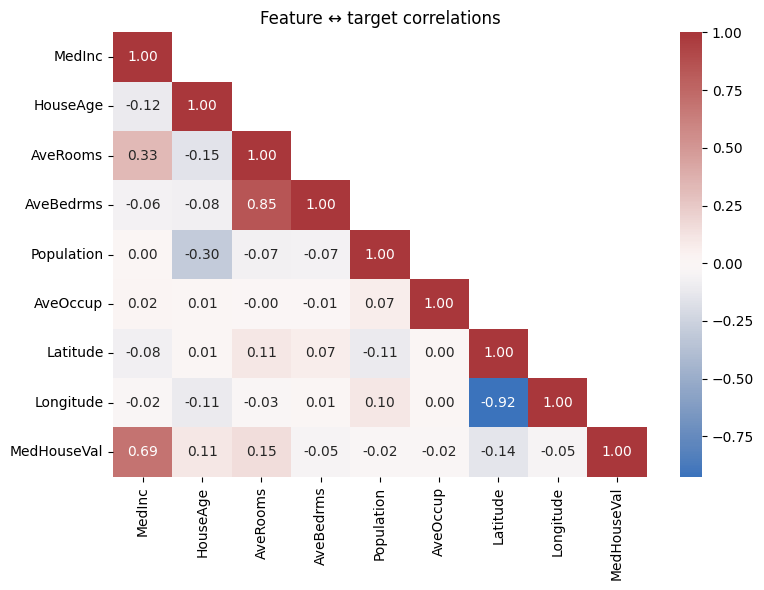

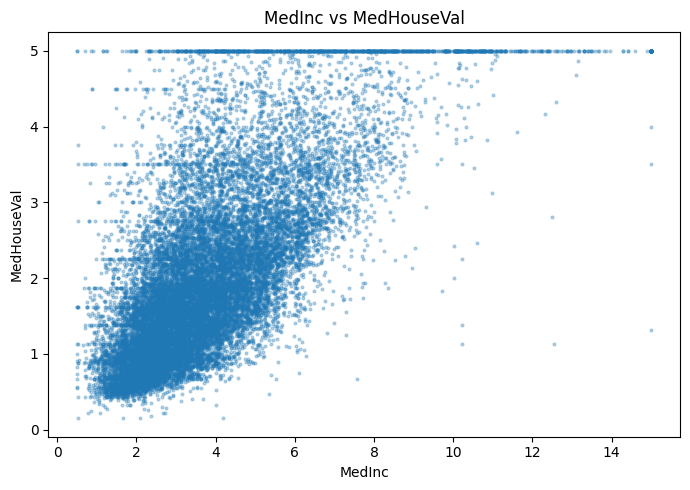

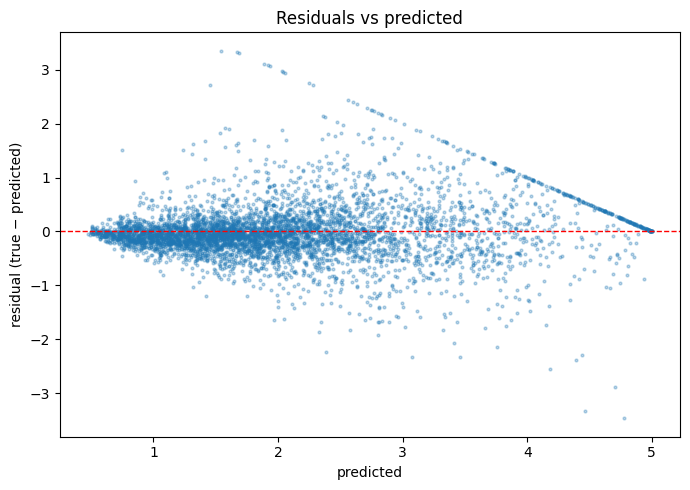

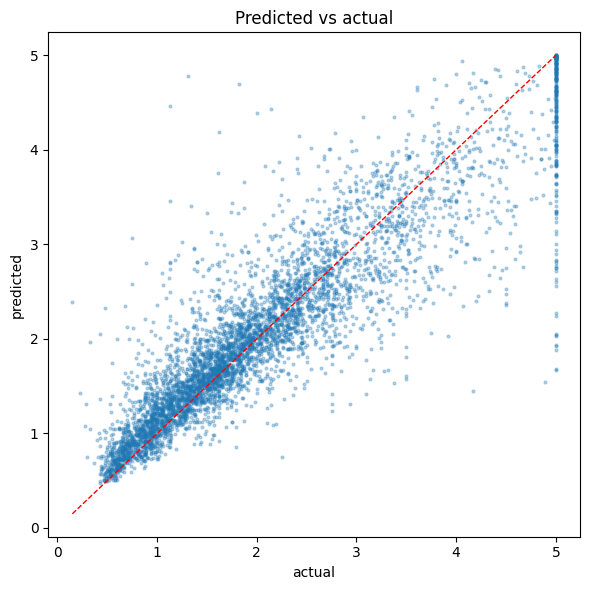

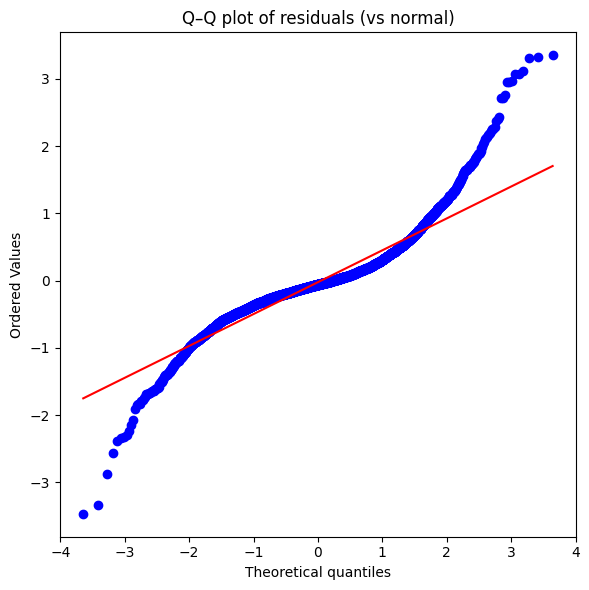

In [6]:
n_trials = 5

with mlflow.start_run(run_name="study") as parent_run:
    mlflow.log_param("n_trials", n_trials)

    # EDA plots \u2014 properties of the *data*, logged once on the parent, not per trial.
    mlflow.log_figure(plot_correlation_heatmap(df), "eda/correlation_heatmap.png")
    mlflow.log_figure(
        plot_feature_vs_target(df, "MedInc", "MedHouseVal"), "eda/medinc_vs_target.png"
    )

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # Promote the winning trial's params + all five metrics onto the parent.
    best_trial = study.best_trial
    mlflow.log_params({f"best_{k}": v for k, v in best_trial.params.items()})
    mlflow.log_metrics(
        {f"best_{k}": v for k, v in best_trial.user_attrs["metrics"].items()}
    )
    mlflow.log_param("best_child_run_id", best_trial.user_attrs["run_id"])

print(f"Best trial: #{best_trial.number}")
print(f"Best MSE:   {study.best_value:.4f}")
print(f"Best params: {best_trial.params}")
print(f"Best metrics: {best_trial.user_attrs['metrics']}")
print(f"Best child run_id: {best_trial.user_attrs['run_id']}")

<div style="text-align: justify; max-width: 90ch">

## Step 6: View the plots in the UI

Open <http://127.0.0.1:5001/>, click into **Logging Plots with MLflow**, and you'll see:

- **One parent run** `study` carrying `n_trials=5`, the EDA plots, and the best trial's params/metrics (prefixed `best_*`).
- **Five child runs** `trial_0` … `trial_4` collapsed under the parent. Each carries its own params, five metrics, three diagnostic plots, and the fitted model.

Click the parent's **Artifacts** tab — you'll see only `eda/`:

```text
eda/
    correlation_heatmap.png
    medinc_vs_target.png
```

Expand the parent, click any child, open its Artifacts tab — you'll see `diagnostics/` and `model/`:

```text
diagnostics/
    predicted_vs_actual.png
    qq.png
    residuals.png
model/
    MLmodel
    model.skops
    …
```

**This is where per-trial plot logging earns its keep.** Click between trials and watch the residuals plot change:

- A trial with too-shallow trees (small `max_depth`) shows a strong tilt or curve in the residuals — the model is underfitting and missing structure.
- A deeper trial flattens the residual band but the predicted-vs-actual scatter tightens around the diagonal — bias drops, variance may rise.
- The best trial usually sits between these extremes, with a roughly flat residual band and the lowest combined MSE/MAE.

**Reading more than one metric.** Two metrics moving together (MSE and RMSE) tells you nothing new — RMSE is √MSE. The interesting signal is when **R² and explained variance diverge**:
that means your predictions have a constant offset (a bias term) on top of their random error, which neither MSE nor RMSE will surface on its own.

</div>

<div style="text-align: justify; max-width: 90ch">

## Exercise (optional): check where each plot landed

Step 6 described the artifact layout: the EDA plots on the parent only, and three diagnostic plots on every child. Check that layout from code, the way a review script would, without opening the UI:

1. List the parent run's artifacts with `MlflowClient().list_artifacts(run_id, path)`: the top level should hold `eda/` and nothing else.
2. Find the study's child runs with `mlflow.search_runs(...)` (hint: filter on `tags.mlflow.parentRunId`, as in the `b_hyperparameter_tuning` exercise) and check that each child's `diagnostics/` folder holds exactly the three PNGs.
3. Download the best trial's `diagnostics/residuals.png` with `mlflow.artifacts.download_artifacts(...)` into a temporary directory and check that it is a non-empty PNG file.

Try it in a new cell, then compare with the solution below. The solution only reads from the server, so running or skipping it leaves the rest of the notebook unchanged.

</div>

<div style="text-align: justify; max-width: 90ch">

### Solution

`list_artifacts` returns one entry per file or folder at the given path. `download_artifacts` fetches a run artifact through the tracking server and returns the local file path.

</div>

In [7]:
import tempfile
from pathlib import Path

from mlflow import MlflowClient

client = MlflowClient()


def artifact_paths(run_id: str, path: str | None = None) -> list[str]:
    return sorted(f.path for f in client.list_artifacts(run_id, path))


parent_id = parent_run.info.run_id
print("parent, top level:", artifact_paths(parent_id))
print("parent, eda/     :", artifact_paths(parent_id, "eda"))

expected = [
    f"diagnostics/{name}.png" for name in ("predicted_vs_actual", "qq", "residuals")
]
children = mlflow.search_runs(
    filter_string=f"tags.mlflow.parentRunId = '{parent_id}'",
).sort_values("tags.mlflow.runName")
print()
for run_id, run_name in zip(children["run_id"], children["tags.mlflow.runName"]):
    print(
        f"{run_name}: the three diagnostic plots = {artifact_paths(run_id, 'diagnostics') == expected}"
    )

with tempfile.TemporaryDirectory() as tmp:
    png = Path(
        mlflow.artifacts.download_artifacts(
            run_id=best_trial.user_attrs["run_id"],
            artifact_path="diagnostics/residuals.png",
            dst_path=tmp,
        )
    )
    is_png = png.read_bytes()[1:4] == b"PNG"
    print(
        f"\nbest trial's residuals.png: non-empty = {png.stat().st_size > 0}, PNG file = {is_png}"
    )

parent, top level: ['eda']


parent, eda/     : ['eda/correlation_heatmap.png', 'eda/medinc_vs_target.png']



trial_0: the three diagnostic plots = True
trial_1: the three diagnostic plots = True


trial_2: the three diagnostic plots = True


trial_3: the three diagnostic plots = True


trial_4: the three diagnostic plots = True



best trial's residuals.png: non-empty = True, PNG file = True


<div style="text-align: justify; max-width: 90ch">

## Next steps

- **[`d_logging_callbacks.ipynb`](./d_logging_callbacks.ipynb)** — the natural advanced follow-on: Optuna callbacks integrated with MLflow,
  contrasting stdout-quietening (`champion_callback`) with MLflow metric history (`mlflow_progress_callback`). Also brings in XGBoost and conditional hyperparameter spaces.
- [MLflow `log_figure` API](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_figure) — supported figure types (matplotlib, plotly), keyword arguments.
- [Logging plots with MLflow (upstream)](https://mlflow.org/docs/latest/ml/traditional-ml/tutorials/hyperparameter-tuning/part2-logging-plots/) —
  the four plot types this notebook skipped (time-series, box, density, coefficients) follow the same pattern.
- **`mlflow.search_runs(...)` for cross-trial analysis** — once metrics and plots are logged per child run, you can pull them back as a DataFrame,
  sort by R², and load the corresponding model with `mlflow.pyfunc.load_model(f"runs:/{run_id}/model")`. This is the foundation for any "compare the top-3 trials" workflow.

</div>